100%|██████████| 9.91M/9.91M [00:03<00:00, 2.63MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 101kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.00MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.47MB/s]


Epoch: 0 Loss: 0.10503364354372025
Epoch: 1 Loss: 0.054432861506938934
Epoch: 2 Loss: 0.05376804992556572
Epoch: 3 Loss: 0.07239701598882675
Epoch: 4 Loss: 0.06071419641375542


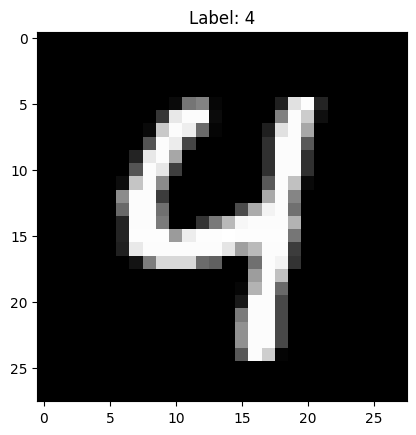

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# Define Neural Network
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = x.view(-1,28*28)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
for epoch in range(5):
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

# Visualization
images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title("Label: " + str(labels[0].item()))
plt.show()